# MSG-TW: Thin-Walled Timoshenko Beam for a Two-Cell Tube

**MSG-TW** reduces a thin-walled composite cross-section to a $6\times6$ Timoshenko beam stiffness from a
1-D shell structure genome (SG). Two shell kinematics are available: the **Reissner–Mindlin (RM)** shell,
which carries an independent through-thickness director and so keeps the **transverse-shear** compliance,
and the **Kirchhoff–Love (KL)** shell, which drops it. This tutorial runs both on the **anisotropic
two-cell $[-45]$ tube** (a single $[-45]$ ply, taken at the **wall-centre reference**) at two wall
thicknesses — thin ($R/h = 12.5$) and thick ($R/h = 3.1$) — directly from the shell SG YAML, and benchmarks
each against the 2-D solid.

The Timoshenko beam stiffness is a $6\times6$ whose rows/columns mean
**1 = extension, 2–3 = transverse shear, 4 = torsion, 5–6 = bending** — the same ordering as a VABS `.K` file.

> RM driver: `strip_RM.rm_timoshenko_6x6(yaml, frac, dshift, curved, shear="mitc")`
> KL driver: `gradient_kirchhoff.gradient_junction_kirchhoff(yaml, frac, dshift)`

In [1]:
import os, sys
import numpy as np
def _find_repo_root(d=None):
    d = os.path.abspath(d or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "examples", "data")) and os.path.isfile(os.path.join(d, "pyproject.toml")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError("OpenSG-TW repo root not found - run this notebook from inside the cloned repo")
        d = parent
CC = _find_repo_root()
for p in (CC, os.path.join(CC, "opensg_jax")):
    if p not in sys.path:
        sys.path.insert(0, p)
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import jax; jax.config.update("jax_enable_x64", True)
np.set_printoptions(precision=4, linewidth=150, suppress=True)
from IPython.display import Image
from fe_jax.orient_plot import plot_orient
from opensg_jax.fe_jax.timo_report import (sym, pcterr, full_pcterr, diag_table, term_table,
                                          compare_terms, print_6x6, nonzero_terms, parse_vabs, wall_t, LBL)
from opensg_jax.fe_jax.strip_RM import rm_timoshenko_6x6
from opensg_jax.fe_jax.gradient_kirchhoff import gradient_junction_kirchhoff
print("environment ready  |  jax", jax.__version__)

environment ready  |  jax 0.9.2


In [2]:
# two-cell [-45] tube at two wall thicknesses, plus the R/h sweep used for the convergence study
SHELL    = os.path.join(CC, "examples", "data", "1d_yaml", "tube2cell_m45_shell.yaml")        # thin, R/h = 12.5
SOLIDY   = os.path.join(CC, "examples", "data", "2d_yaml", "tube2cell_m45_solid.yaml")
BENCH    = os.path.join(CC, "examples", "data", "benchmark", "tube2cell_m45_solid_ref.txt")   # 2-D solid 6x6 (thin)
SWEEP    = os.path.join(CC, "examples", "data", "sweep_2cell")
SHELL_TK = os.path.join(SWEEP, "shell_rh031.yaml")                                            # thick, R/h = 3.1
BENCH_TK = os.path.join(SWEEP, "C6_solid_rh031.txt")                                          # 2-D solid 6x6 (thick)
T, T_TK = wall_t(SHELL), wall_t(SHELL_TK)
NEG = 2000.0                          # neglect threshold: keep all terms incl. EI3 (~ max/1040 for the thin tube)
print("two-cell [-45] tube  |  thin: t=%.4f m, R/h=%.1f     thick: t=%.4f m, R/h=%.1f"
      % (T, 0.05 / T, T_TK, 0.05 / T_TK))

two-cell [-45] tube  |  thin: t=0.0040 m, R/h=12.5     thick: t=0.0160 m, R/h=3.1


## 1 · Cross-section: geometry & reference

The 2-D solid mesh of the two-cell tube (a circular $[-45]$ wall split by a diametral shear web). The dashed
red line is the **wall-centre reference** at radius $R$ — the surface at which the 1-D shell ABD is taken
(`dshift = t/2`), so the shell and solid share the same beam reference axis.

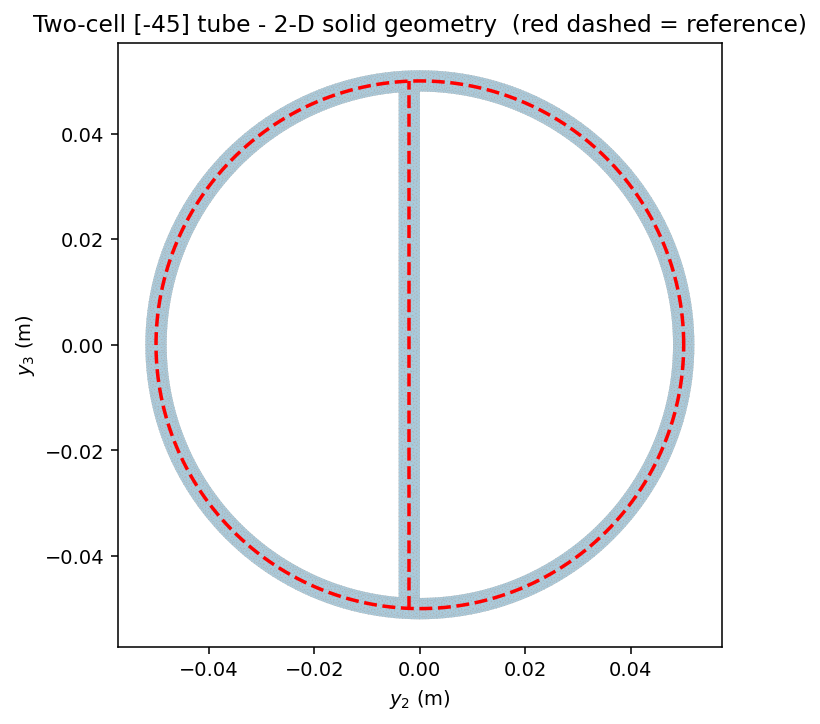

In [3]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from opensg_jax.fe_jax.segment import read_solid_yaml
sg = read_solid_yaml(SOLIDY)
nd, cells, dom, mp = sg["points"], sg["cells"], sg["cell_domain_ids"], sg["material_param"]
uniq, inv = np.unique(mp[dom], axis=0, return_inverse=True)      # same material/layup -> same colour
palette = ["#a6cee3", "#fdbf6f", "#b2df8a", "#fb9a99", "#cab2d6", "#ffff99"]
fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.add_collection(PolyCollection([nd[c] for c in cells], facecolors=[palette[i % len(palette)] for i in inv],
                                 edgecolors="0.6", linewidths=0.08))
ax.autoscale_view()
cent = np.array([nd[c].mean(0) for c in cells])
web_xc = cent[np.hypot(cent[:, 0], cent[:, 1]) < 0.046, 0].mean()   # web centre (the web sits inside the ring)
th = np.linspace(0, 2 * np.pi, 240)
ax.plot(0.05 * np.cos(th), 0.05 * np.sin(th), "r--", lw=1.8)        # wall-centre reference
ax.plot([web_xc, web_xc], [-0.05, 0.05], "r--", lw=1.8)            # web-centre reference
ax.set_aspect("equal"); ax.set_title("Two-cell [-45] tube - 2-D solid geometry  (red dashed = reference)")
ax.set_xlabel(r"$y_2$ (m)"); ax.set_ylabel(r"$y_3$ (m)")
png = os.path.join(CC, "docs", "tutorials", "_img", "twocell_geom_ref.png")
fig.savefig(png, dpi=140, bbox_inches="tight"); plt.close(fig)
Image(filename=png)

## 2 · Material orientation

Per-element material axes on the shell and solid meshes: **$e_2$ (blue)** is the in-plane ply direction and
**$e_3$ (green)** is the wall normal.

[orient_plot] wrote docs/tutorials/_img/twocell_rm_orient.png


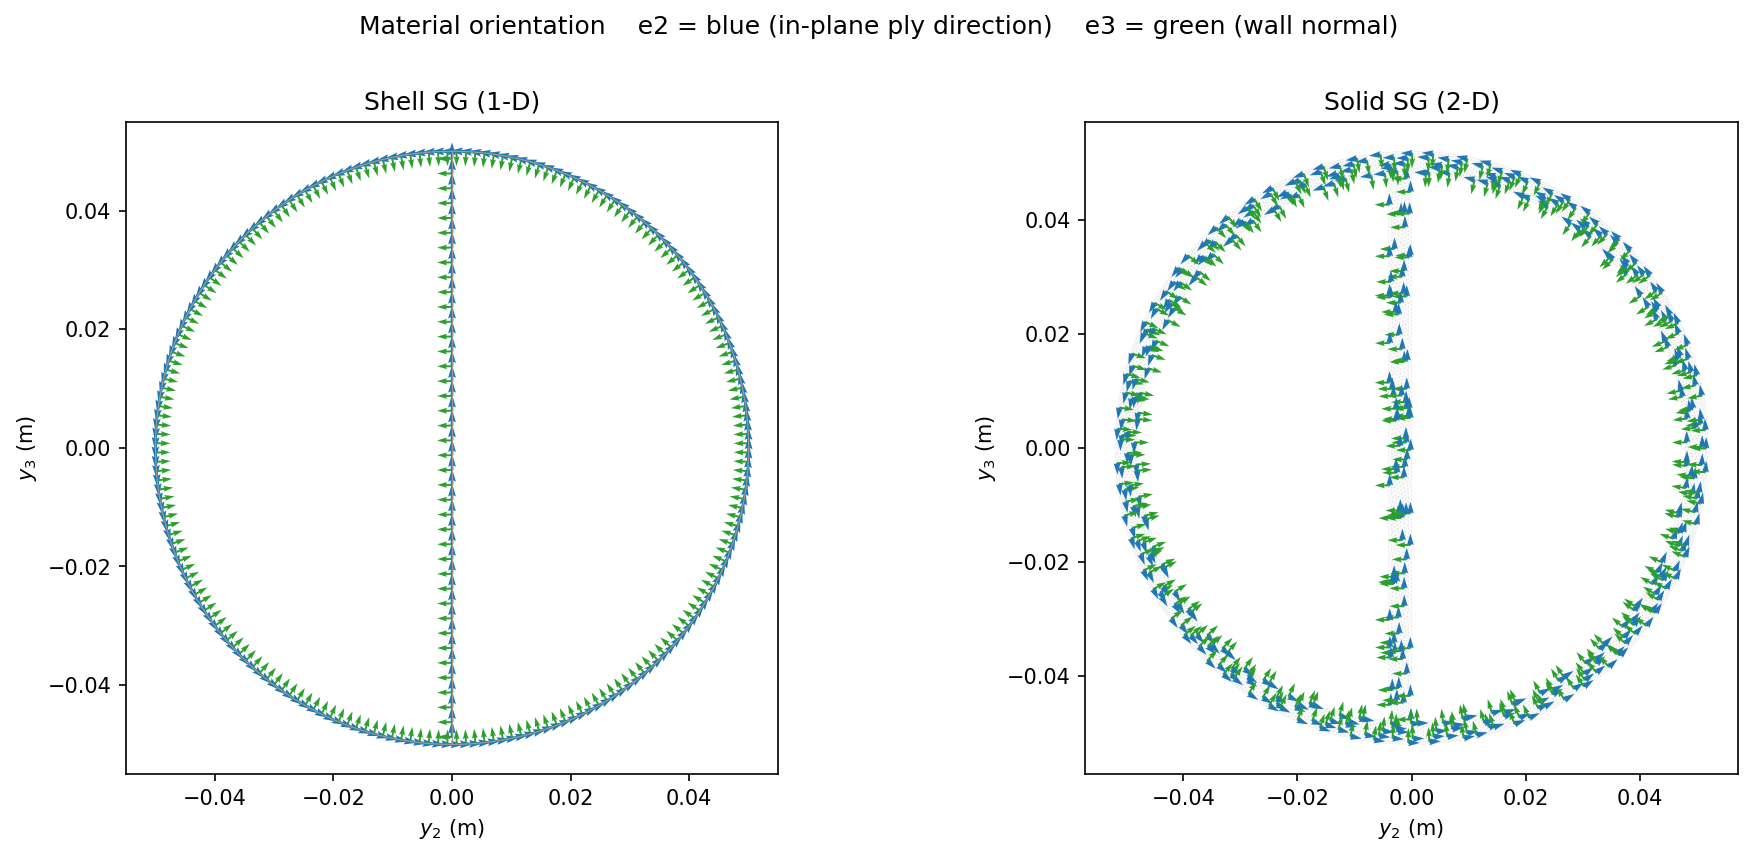

In [4]:
png = plot_orient(SHELL, SOLIDY, out_png=os.path.join(CC, "docs", "tutorials", "_img", "twocell_rm_orient.png"), side_by_side=True)
Image(filename=png)

## 3 · MSG-RM: thin & thick wall

Run the Reissner–Mindlin solve for both walls and print the full 6×6 and the per-wall solve time. Order is the VABS `.K` convention `[EA, GA2, GA3, GJ, EI2, EI3]` = 1 extension / 2–3 transverse shear / 4 torsion / 5–6 bending. The per-term benchmark against the 2-D solid is in section 5.

> **Note on timing:** each model's *thin* solve is its **first call**, so it also carries JAX's one-time JIT compilation (large for KL, ~11 s); the *thick* figure is the steady per-wall cost (KL ≈ 3 s, RM ≈ 0.8 s). The two walls have the same mesh, so the real per-solve cost is essentially equal — the gap is compilation, not problem size.

In [5]:
import time
t0 = time.perf_counter()
C_rm    = sym(rm_timoshenko_6x6(SHELL,    0.0, dshift=T    / 2, curved=True, shear="mitc", orient=False))
t_rm_thin = time.perf_counter() - t0
t0 = time.perf_counter()
C_rm_tk = sym(rm_timoshenko_6x6(SHELL_TK, 0.0, dshift=T_TK / 2, curved=True, shear="mitc", orient=False))
t_rm_thick = time.perf_counter() - t0
print("RM  thin wall  (R/h = 12.5)  -  Timoshenko beam stiffness 6x6:")
print(C_rm)
print("\nRM  thick wall (R/h = 3.1)   -  Timoshenko beam stiffness 6x6:")
print(C_rm_tk)
print("\nRM solve time:   thin %.2f s   thick %.2f s   (thin = first call, includes JIT compile)"
      % (t_rm_thin, t_rm_thick))

RM  thin wall  (R/h = 12.5)  -  Timoshenko beam stiffness 6x6:
[[20210148.7738       -0.1028 -1223175.3495  -210883.5897       -0.0024     -391.4396]
 [      -0.1028  4437983.2299        0.6154       -0.       104005.1206        0.0087]
 [-1223175.3495        0.6154  7323760.8033     -435.0868        0.0144   103686.4707]
 [ -210883.5897       -0.         -435.0868    23494.4875       -0.            3.4489]
 [      -0.0024   104005.1206        0.0144       -0.        22866.2538        0.0002]
 [    -391.4396        0.0087   103686.4707        3.4489        0.0002    19175.9887]]

RM  thick wall (R/h = 3.1)   -  Timoshenko beam stiffness 6x6:
[[80838507.0234       -0.3137 -4912990.061   -844347.1848       -0.0073    -2023.1694]
 [      -0.3137 20708754.9035        1.9282       -0.0013   478831.3763        0.027 ]
 [-4912990.061         1.9282 30198255.0374   -20743.8367        0.0446   422109.0451]
 [ -844347.1848       -0.0013   -20743.8367   100277.1232       -0.          208.7649]
 [

## 4 · Kirchhoff–Love: thin & thick wall

The same two walls through the Kirchhoff–Love driver `gradient_junction_kirchhoff` (Hermite-$C^1$, no transverse shear), reporting its own solve time — note how much cheaper KL is than RM. The benchmark is in section 5.

In [6]:
import time
t0 = time.perf_counter()
C_kl    = sym(gradient_junction_kirchhoff(SHELL,    frac=0.0, dshift=T    / 2, orient=False)[0])
t_kl_thin = time.perf_counter() - t0
t0 = time.perf_counter()
C_kl_tk = sym(gradient_junction_kirchhoff(SHELL_TK, frac=0.0, dshift=T_TK / 2, orient=False)[0])
t_kl_thick = time.perf_counter() - t0
print("KL  thin wall  (R/h = 12.5)  -  Timoshenko beam stiffness 6x6:")
print(C_kl)
print("\nKL  thick wall (R/h = 3.1)   -  Timoshenko beam stiffness 6x6:")
print(C_kl_tk)
print("\nKL solve time:   thin %.2f s   thick %.2f s   (thin = first call, includes JIT compile)"
      % (t_kl_thin, t_kl_thick))

KL  thin wall  (R/h = 12.5)  -  Timoshenko beam stiffness 6x6:
[[20197348.2049     8752.6978 -1106931.4649  -210811.6003      250.7302     1189.7842]
 [    8752.6978  3868949.5758   -10591.3894    -1202.3015    90919.655     -1120.8088]
 [-1106931.4649   -10591.3894  6513516.663      -141.8618     -594.7187    92716.7175]
 [ -210811.6003    -1202.3015     -141.8618    23476.1413      -27.9385        7.3336]
 [     250.7302    90919.655      -594.7187      -27.9385    22562.894       -31.7231]
 [    1189.7842    -1120.8088    92716.7175        7.3336      -31.7231    19029.1006]]

KL  thick wall (R/h = 3.1)   -  Timoshenko beam stiffness 6x6:
[[80548007.2056    46190.6503 -1903726.9619  -839162.5911     -584.3748    40269.6882]
 [   46190.6503  6311598.6793     3641.2407   -19240.805    147193.508    -20885.6302]
 [-1903726.9619     3641.2407 11541862.9745    -7378.6002     9851.7462   163465.5387]
 [ -839162.5911   -19240.805     -7378.6002    99197.6884     -453.7223      461.7523]
 [

## 5 · RM vs KL vs the 2-D solid

Side-by-side per-term comparison. On the thin wall both models are close to the solid; on the thick wall the KL transverse-shear terms `GA2`, `GA3` fall away while RM stays bounded.

In [7]:
S    = sym(np.loadtxt(BENCH))                                 # 2-D solid reference (thin)
S_TK = sym(np.loadtxt(BENCH_TK))                              # 2-D solid reference (thick)
print("Thin wall  (R/h = 12.5)  -  RM and KL vs 2-D solid:")
compare_terms(S, {"RM": C_rm, "KL": C_kl}, neglect=NEG)
print("\nThick wall (R/h = 3.1)   -  RM and KL vs 2-D solid:")
compare_terms(S_TK, {"RM": C_rm_tk, "KL": C_kl_tk}, neglect=NEG)

Thin wall  (R/h = 12.5)  -  RM and KL vs 2-D solid:
  term             solid/ref             RM      RM%d             KL      KL%d
  C11(EA)         2.0008e+07     2.0210e+07    +1.01     2.0197e+07    +0.95
  C13            -1.1976e+06    -1.2232e+06    +2.13    -1.1069e+06    -7.57
  C14            -2.0915e+05    -2.1088e+05    +0.83    -2.1081e+05    +0.79
  C22(GA2)        4.4880e+06     4.4380e+06    -1.11     3.8689e+06   -13.79
  C25             1.0449e+05     1.0401e+05    -0.46     9.0920e+04   -12.99
  C33(GA3)        7.3348e+06     7.3238e+06    -0.15     6.5135e+06   -11.20
  C36             1.0126e+05     1.0369e+05    +2.40     9.2717e+04    -8.43
  C44(GJ)         2.3570e+04     2.3494e+04    -0.32     2.3476e+04    -0.40
  C55(EI2)        2.2482e+04     2.2866e+04    +1.71     2.2563e+04    +0.36
  C66(EI3)        1.9222e+04     1.9176e+04    -0.24     1.9029e+04    -1.00

Thick wall (R/h = 3.1)   -  RM and KL vs 2-D solid:
  term             solid/ref             RM   

## 6 · Convergence: RM & KL error vs R/h

Sweep the two-cell tube from thin (R/h = 12.5) to thick (R/h = 3.1) and track the % error of the **transverse-shear terms (GA2, GA3) and their couplings** — the terms that separate the two models — against the 2-D solid. RM keeps them within a few % until the wall is genuinely thick; KL has no transverse shear, so they collapse.

R/h = 12.50   done


R/h = 10.00   done


R/h =  8.00   done


R/h =  6.25   done


R/h =  5.00   done


R/h =  4.00   done


R/h =  3.12   done


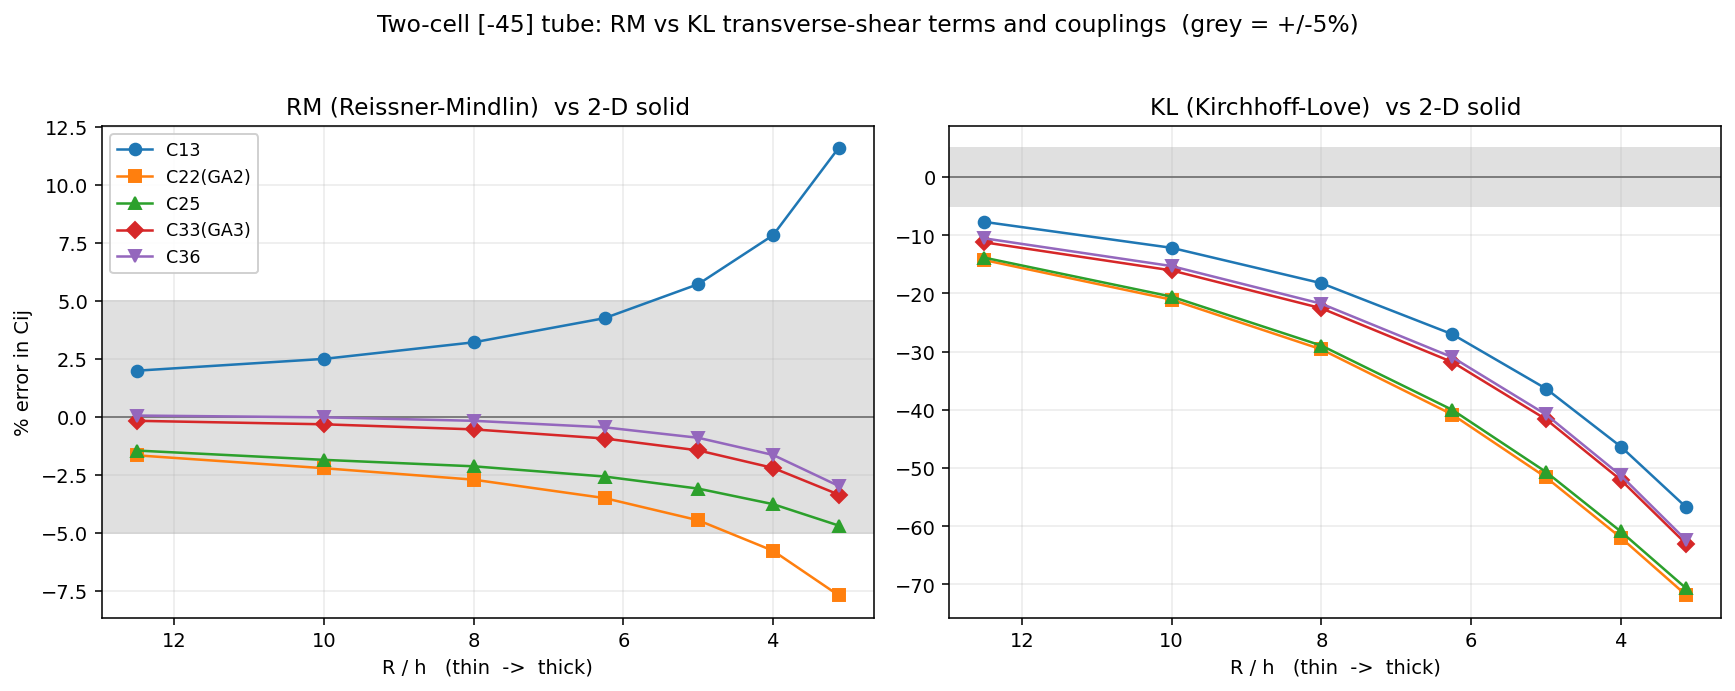

In [8]:
import io, contextlib
import matplotlib.pyplot as plt
TAGS = ["rh125", "rh100", "rh080", "rh062", "rh050", "rh040", "rh031"]
RH, C_RM, C_KL, SREF = [], [], [], []
for tg in TAGS:
    ys = os.path.join(SWEEP, "shell_%s.yaml" % tg)
    ss = sym(np.loadtxt(os.path.join(SWEEP, "C6_solid_%s.txt" % tg)))
    tt = wall_t(ys)
    with contextlib.redirect_stdout(io.StringIO()):            # hush the per-solve solver prints
        crm = sym(rm_timoshenko_6x6(ys, 0.0, dshift=tt / 2, curved=True, shear="mitc", orient=False))
        ckl = sym(gradient_junction_kirchhoff(ys, frac=0.0, dshift=tt / 2, orient=False)[0])
    RH.append(0.05 / tt); C_RM.append(crm); C_KL.append(ckl); SREF.append(ss)
    print("R/h = %5.2f   done" % (0.05 / tt))
RH = np.array(RH)
terms = [(i, j, tag) for (i, j, tag) in nonzero_terms(SREF[0], NEG)
         if i in (1, 2) or j in (1, 2)]                        # transverse-shear terms (GA2, GA3) + couplings
def term_err(Cs, i, j):
    return np.array([100.0 * (Cs[k][i, j] - SREF[k][i, j]) / SREF[k][i, j] for k in range(len(TAGS))])

MARKERS = ["o", "s", "^", "D", "v", "P", "X"]
fig, axs = plt.subplots(1, 2, figsize=(12.5, 5.0))
for ax, Cs, name in [(axs[0], C_RM, "RM (Reissner-Mindlin)"), (axs[1], C_KL, "KL (Kirchhoff-Love)")]:
    ax.axhspan(-5, 5, color="0.88", zorder=0)
    ax.axhline(0, color="0.4", lw=0.8)
    for m, (i, j, tag) in enumerate(terms):
        ax.plot(RH, term_err(Cs, i, j), marker=MARKERS[m % len(MARKERS)], ms=6, lw=1.3, label=tag)
    ax.set_title("%s  vs 2-D solid" % name)
    ax.set_xlabel("R / h   (thin  ->  thick)"); ax.invert_xaxis()
    ax.grid(alpha=0.25)
axs[0].set_ylabel("% error in Cij")
axs[0].legend(ncol=1, fontsize=9, loc="best", framealpha=0.92)    # single legend (both panels share the term set)
fig.suptitle("Two-cell [-45] tube: RM vs KL transverse-shear terms and couplings  (grey = +/-5%)", fontsize=12)
png = os.path.join(CC, "docs", "tutorials", "_img", "twocell_convergence.png")
fig.tight_layout(rect=[0, 0, 1, 0.95]); fig.savefig(png, dpi=140, bbox_inches="tight"); plt.close(fig)
Image(filename=png)

## Takeaway

- The MSG-RM shell recovers the full 6×6 Timoshenko stiffness of the multi-cell composite tube from a 1-D cross-section, referenced at the **wall centre** (`dshift = t/2`), at a fraction of the cost of the 2-D solid.
- On the **thin** wall (R/h = 12.5) RM and KL agree with the solid on the classical terms; on the **thick** wall (R/h = 3.1) only RM keeps the transverse-shear `GA2`, `GA3` within a few %.
- The convergence sweep makes the split explicit: RM tracks the solid across the whole R/h range, KL diverges on the shear terms as the wall thickens — the regime where the Reissner–Mindlin kinematics are needed.